<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Temperature_Forecasting(365_Days).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

#Create Large Temperature Dataset

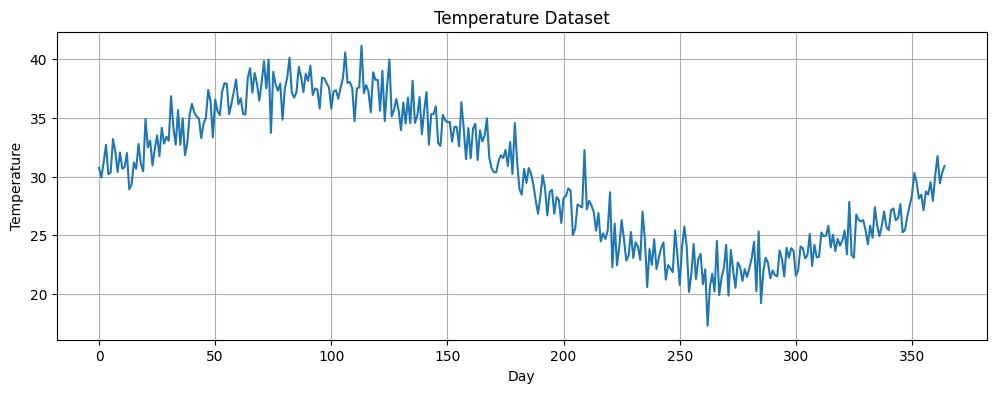

In [18]:
days = np.arange(365)

temperature = (
    30
    + 8*np.sin(days*2*np.pi/365)
    + np.random.normal(0,1.5,365)
)

plt.figure(figsize=(12,4))
plt.plot(temperature)
plt.title("Temperature Dataset")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

#Normalize

In [19]:
scaler=MinMaxScaler()

temperature = scaler.fit_transform(
    temperature.reshape(-1,1)
)

#Create Sliding Window

In [20]:
window_size=30

X=[]
y=[]

for i in range(len(temperature)-window_size):
    X.append(temperature[i:i+window_size])
    y.append(temperature[i+window_size])

X=np.array(X)
y=np.array(y)

In [21]:
print(X.shape)
print(y.shape)

(335, 30, 1)
(335, 1)


#Train-Test Split

In [22]:
split=int(0.8*len(X))

X_train=X[:split]
y_train=y[:split]

X_test=X[split:]
y_test=y[split:]

In [23]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(268, 30, 1)
(268, 1)
(67, 30, 1)
(67, 1)


#Build Advanced RNN

In [24]:
from tensorflow.keras.layers import SimpleRNN

model = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(window_size,1)),
    Dropout(0.2),

    SimpleRNN(64),

    Dense(32, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
from sklearn import metrics
model.compile(
    loss="mse",
    optimizer="adam",
    metrics=[
        "mae",

    ]
)


In [26]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True
)

checkpoint = ModelCheckpoint(

    "best_temperature_rnn.keras",

    save_best_only=True
)

In [27]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test,y_test),

    epochs=200,

    callbacks=[

        early_stop,

        checkpoint,
        reduce_lr

    ],

    batch_size=16,

    verbose=1
)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0878 - mae: 0.2225 - val_loss: 0.0090 - val_mae: 0.0824 - learning_rate: 0.0010
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0167 - mae: 0.1048 - val_loss: 0.0135 - val_mae: 0.1057 - learning_rate: 0.0010
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0145 - mae: 0.0971 - val_loss: 0.0081 - val_mae: 0.0790 - learning_rate: 0.0010
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0129 - mae: 0.0906 - val_loss: 0.0086 - val_mae: 0.0815 - learning_rate: 0.0010
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0095 - mae: 0.0788 - val_loss: 0.0050 - val_mae: 0.0590 - learning_rate: 0.0010
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0091 - mae: 0.0756 - val_loss: 0.0030 - val_mae: 0.0438 - learning_rate: 0.0010
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0077 - mae: 0.0686 - val_loss: 0.0032 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 

#Plot Loss

In [28]:
best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best Epoch :", best_epoch)
print("Best Validation Loss :", min(history.history["val_loss"]))

Best Epoch : 17
Best Validation Loss : 0.002675258321687579


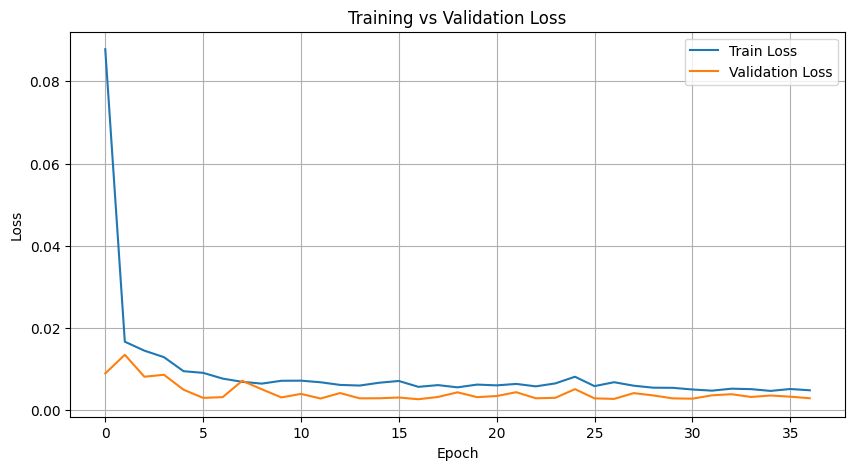

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step


#Calculating All types of Errors

In [31]:
mse = mean_squared_error(actual,pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(actual,pred)

print("MAE :",mae)

print("RMSE :",rmse)

print("MSE :",mse)

MAE : 1.0241393579381246
RMSE : 1.2330462817668038
MSE : 1.52040313297894


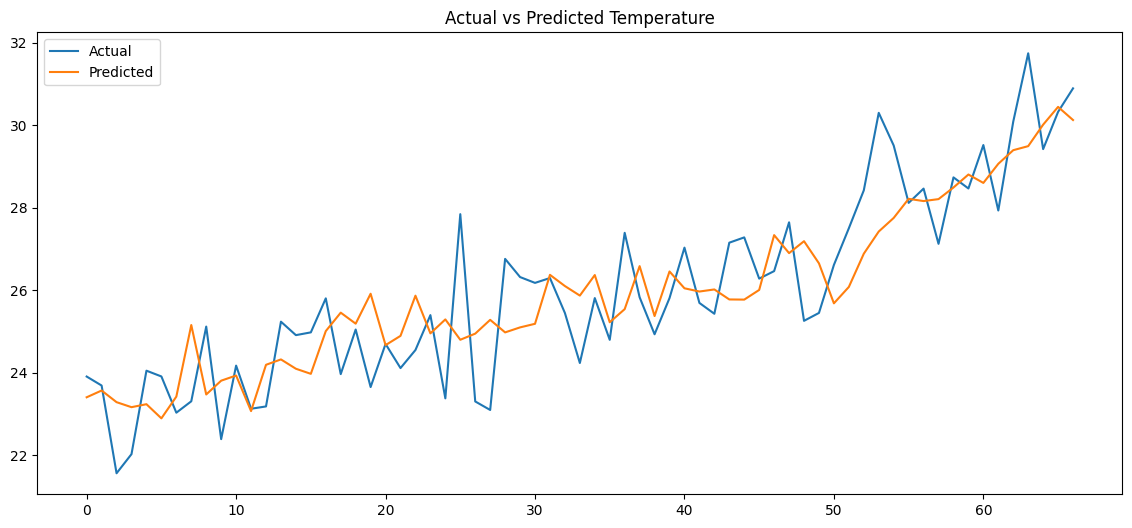

In [32]:
plt.figure(figsize=(14,6))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Temperature")

plt.show()

#Make Prediction on Next 7 Days

In [33]:
last_window = temperature[-window_size:]

future = []

current = last_window.copy()

for i in range(7):

    prediction = model.predict(

        current.reshape(1,window_size,1),

        verbose=0

    )

    future.append(prediction[0,0])

    current = np.append(

        current[1:],

        prediction

    )

future = scaler.inverse_transform(

    np.array(future).reshape(-1,1)

)

print("Next 7 Days Temperature")

for i,temp in enumerate(future):

    print(

        f"Day {i+1}: {temp[0]:.2f}°C"

    )

Next 7 Days Temperature
Day 1: 30.33°C
Day 2: 30.80°C
Day 3: 31.35°C
Day 4: 31.46°C
Day 5: 31.60°C
Day 6: 31.70°C
Day 7: 31.31°C


#visualization of 7 Days Predictions

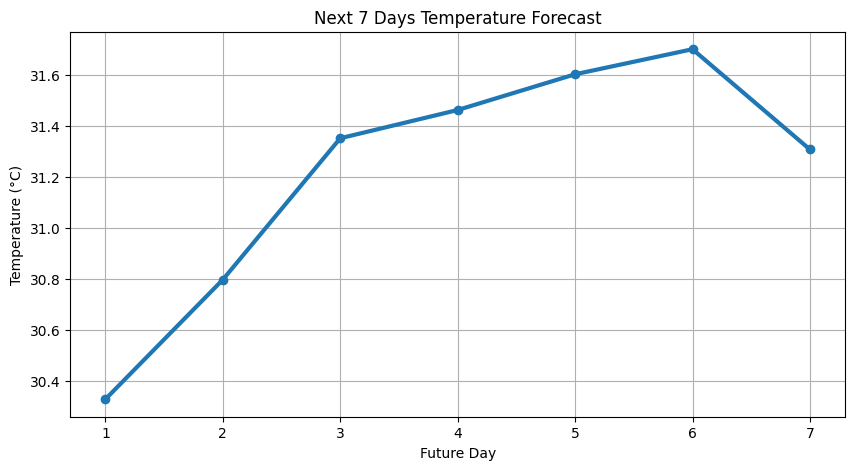

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1,8),
    future,
    marker='o',
    linewidth=3
)

plt.title("Next 7 Days Temperature Forecast")

plt.xlabel("Future Day")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

#Error Distribution

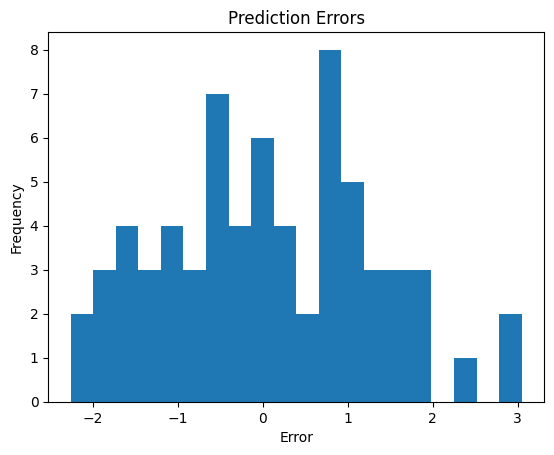

In [35]:
errors = actual.flatten() - pred.flatten()

plt.hist(errors, bins=20)

plt.title("Prediction Errors")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()